# ☕ Notebook 2 — Chemical Pulse
**Dataset:** `arabica_data_cleaned.csv` + `robusta_data_cleaned.csv` (CQI)

**Story:** Climate shifts alter the chemical fingerprint of the bean — acidity, body, aroma.

**Outputs:** `data/processed/chem_processed.csv` · `models/quality_scorer.pkl`

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import warnings, os, joblib
warnings.filterwarnings('ignore')

ROOT = os.path.abspath('..')
RAW  = os.path.join(ROOT,'data','raw')
PROC = os.path.join(ROOT,'data','processed')
MDL  = os.path.join(ROOT,'models')
os.makedirs(PROC, exist_ok=True)
os.makedirs(MDL,  exist_ok=True)

sns.set_theme(style='darkgrid')
C_BROWN='#6F4E37'; C_RED='#E84855'; C_BLUE='#2E86AB'; C_GOLD='#F5A623'
print('Libraries loaded ✓')

Libraries loaded ✓


## 1 · Load & Combine CQI Data

In [35]:
ara = pd.read_csv(os.path.join(RAW,'arabica_data_cleaned.csv'))
rob = pd.read_csv(os.path.join(RAW,'robusta_data_cleaned.csv'))

print('Arabica shape:', ara.shape)
print('Robusta shape:', rob.shape)
print('\nArabica columns:', ara.columns.tolist())
print('\nRobusta columns:', rob.columns.tolist())

Arabica shape: (1311, 44)
Robusta shape: (28, 44)

Arabica columns: ['Unnamed: 0', 'Species', 'Owner', 'Country.of.Origin', 'Farm.Name', 'Lot.Number', 'Mill', 'ICO.Number', 'Company', 'Altitude', 'Region', 'Producer', 'Number.of.Bags', 'Bag.Weight', 'In.Country.Partner', 'Harvest.Year', 'Grading.Date', 'Owner.1', 'Variety', 'Processing.Method', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean.Cup', 'Sweetness', 'Cupper.Points', 'Total.Cup.Points', 'Moisture', 'Category.One.Defects', 'Quakers', 'Color', 'Category.Two.Defects', 'Expiration', 'Certification.Body', 'Certification.Address', 'Certification.Contact', 'unit_of_measurement', 'altitude_low_meters', 'altitude_high_meters', 'altitude_mean_meters']

Robusta columns: ['Unnamed: 0', 'Species', 'Owner', 'Country.of.Origin', 'Farm.Name', 'Lot.Number', 'Mill', 'ICO.Number', 'Company', 'Altitude', 'Region', 'Producer', 'Number.of.Bags', 'Bag.Weight', 'In.Country.Partner', 'Harvest.Year', 'Grading.Date',

In [36]:
ara['Species'] = 'Arabica'
rob['Species'] = 'Robusta'

# Robusta uses 'Salt / Acid' instead of 'Acidity', 'Bitter / Sweet' instead of 'Sweetness'
rob = rob.rename(columns={
    'Salt / Acid':   'Acidity',
    'Bitter / Sweet':'Sweetness',
    'Fragrance / Aroma': 'Aroma',
})

# Quality scoring columns present in both
QUALITY_COLS = ['Aroma','Flavor','Aftertaste','Acidity','Body','Balance',
                'Uniformity','Clean Cup','Sweetness','Total Cup Points']
QUALITY_COLS = [c for c in QUALITY_COLS if c in ara.columns and c in rob.columns]

META_COLS = ['Species','Country of Origin','Harvest Year',
             'altitude_mean_meters','Processing Method','Variety']
META_COLS = [c for c in META_COLS if c in ara.columns and c in rob.columns]

df = pd.concat([ara, rob], ignore_index=True)
print('Combined shape:', df.shape)
print('Quality columns used:', QUALITY_COLS)

Combined shape: (1339, 49)
Quality columns used: ['Flavor', 'Aftertaste', 'Balance']


## 2 · Clean

In [37]:
df = df.rename(columns={
    'Country.of.Origin': 'Country',
    'Harvest.Year':      'Year',
    'Total.Cup.Points':'Total Cup Points'
})

# Parse Year — CQI uses formats like '2013', '2013/2014', 'May-August 2014'
df['Year'] = df['Year'].astype(str).str.extract(r'(\d{4})')[0]
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Clean altitude
if 'altitude_mean_meters' in df.columns:
    df['altitude_mean_meters'] = pd.to_numeric(df['altitude_mean_meters'], errors='coerce')
    df.loc[df['altitude_mean_meters'] > 4500, 'altitude_mean_meters'] = np.nan  # outliers

# Numeric quality cols
for c in QUALITY_COLS:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# df = df.rename(columns={'Total.Cup.Points':'Total Cup Points'})
df = df.dropna(subset=['Total Cup Points','Country'])
df = df[df['Total Cup Points'] > 60]  # remove obvious errors

print('Clean shape:', df.shape)
print('Countries:', df['Country'].nunique())
print('Species:', df['Species'].value_counts().to_dict())
df[QUALITY_COLS].describe()

Clean shape: (1336, 49)
Countries: 36
Species: {'Arabica': 1308, 'Robusta': 28}


,Flavor,Aftertaste,Balance
count,1336.000000,1336.000000,1336.000000
mean,7.527268,7.407904,7.524289
std,0.340169,0.348941,0.353121
min,6.080000,6.170000,5.250000
25%,7.330000,7.250000,7.330000
50%,7.580000,7.420000,7.500000
75%,7.750000,7.602500,7.750000
max,8.830000,8.670000,8.750000


## 3 · EDA — Quality Profiles

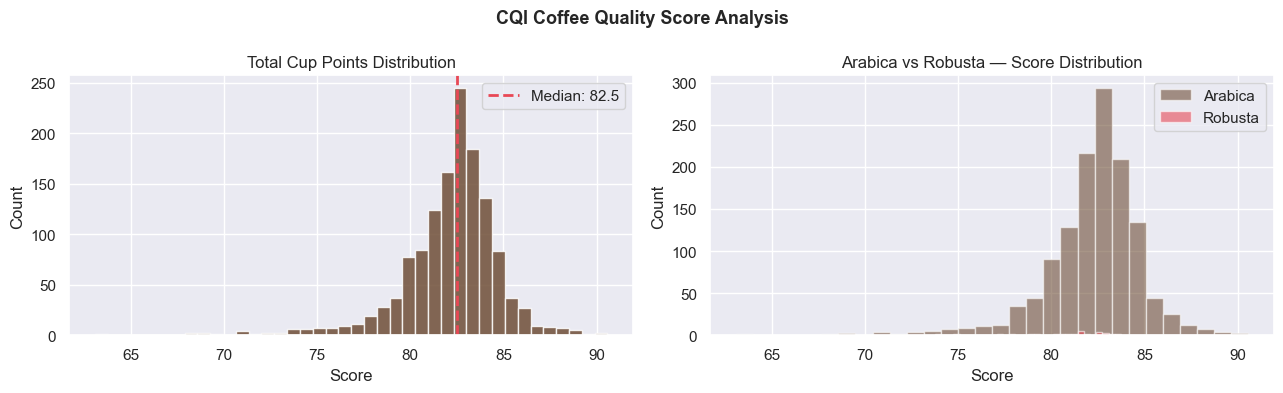

In [38]:
# ── 3a. Total Cup Points distribution ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['Total Cup Points'], bins=40, color=C_BROWN, edgecolor='white', alpha=0.85)
axes[0].axvline(df['Total Cup Points'].median(), color=C_RED, ls='--', lw=2,
                label=f'Median: {df["Total Cup Points"].median():.1f}')
axes[0].set(title='Total Cup Points Distribution', xlabel='Score', ylabel='Count')
axes[0].legend()

for sp, color in [('Arabica', C_BROWN), ('Robusta', C_RED)]:
    sub = df[df['Species']==sp]['Total Cup Points']
    axes[1].hist(sub, bins=30, alpha=0.6, color=color, edgecolor='white', label=sp)
axes[1].set(title='Arabica vs Robusta — Score Distribution', xlabel='Score', ylabel='Count')
axes[1].legend()

plt.suptitle('CQI Coffee Quality Score Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROC,'chem_01_score_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

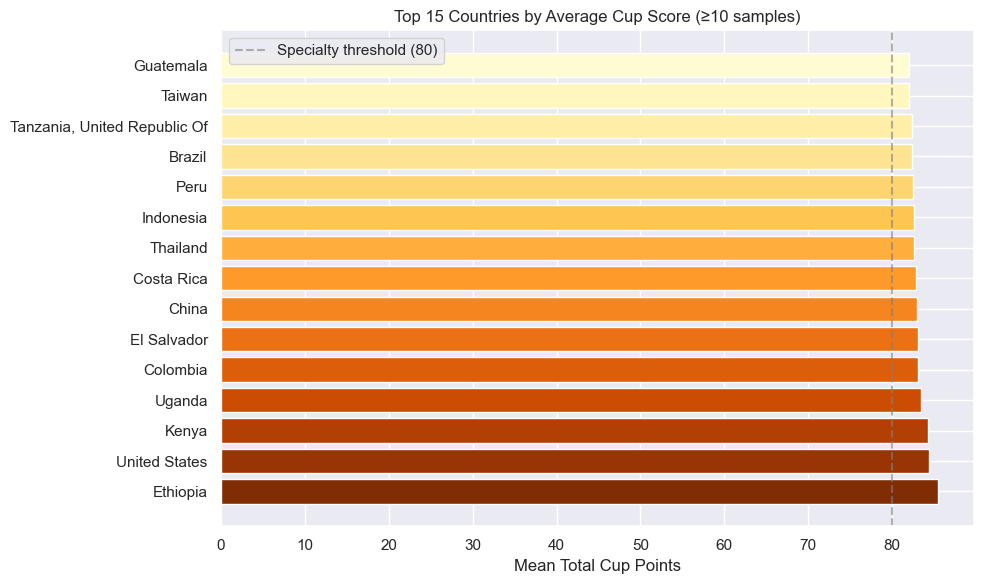

In [39]:
# ── 3b. Top countries by quality ─────────────────────────────
top_countries = (df.groupby('Country')['Total Cup Points']
                   .agg(['mean','count'])
                   .query('count >= 10')
                   .sort_values('mean', ascending=False)
                   .head(15).reset_index())

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_countries['Country'], top_countries['mean'],
               color=sns.color_palette('YlOrBr_r', len(top_countries)))
ax.axvline(80, color='gray', ls='--', alpha=0.6, label='Specialty threshold (80)')
ax.set(title='Top 15 Countries by Average Cup Score (≥10 samples)',
       xlabel='Mean Total Cup Points')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PROC,'chem_02_top_countries.png'), dpi=150, bbox_inches='tight')
plt.show()

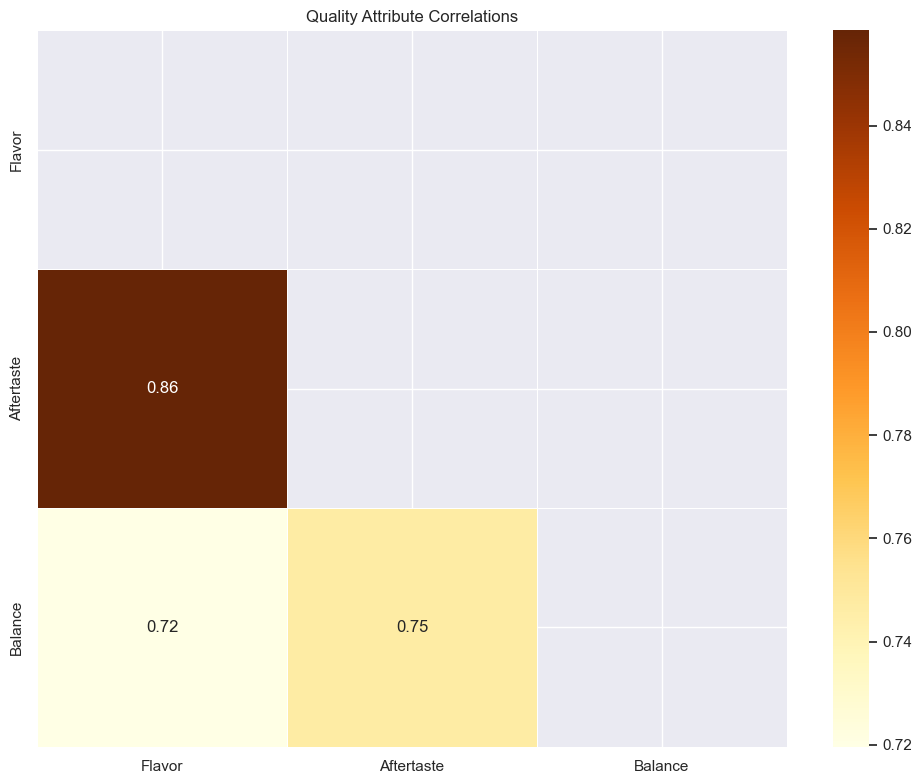

In [40]:
# ── 3c. Correlation heatmap of quality attributes ─────────────
radar_cols = [c for c in QUALITY_COLS if c != 'Total Cup Points']
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(df[QUALITY_COLS].corr(), dtype=bool))
sns.heatmap(df[QUALITY_COLS].corr(), mask=mask, annot=True, fmt='.2f',
            cmap='YlOrBr', linewidths=0.5, ax=ax)
ax.set_title('Quality Attribute Correlations', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PROC,'chem_03_quality_corr.png'), dpi=150, bbox_inches='tight')
plt.show()

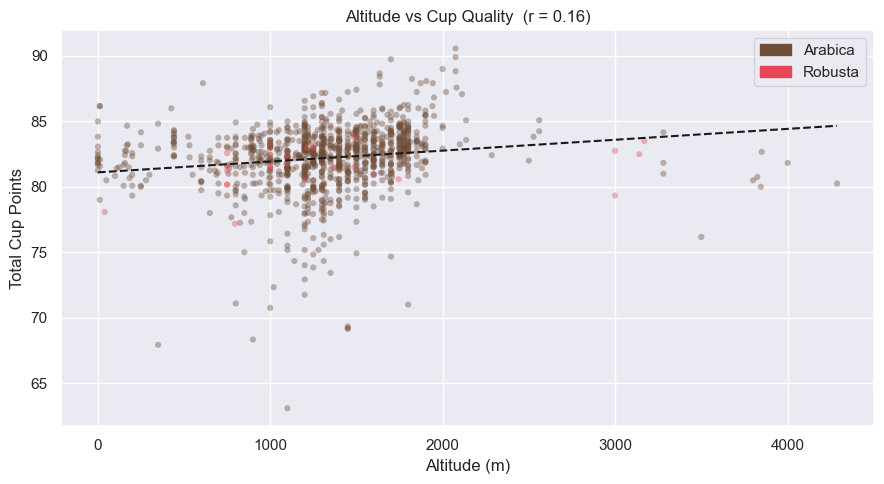

In [41]:
# ── 3d. Altitude vs Quality ──────────────────────────────────
if 'altitude_mean_meters' in df.columns:
    df_alt = df.dropna(subset=['altitude_mean_meters'])
    fig, ax = plt.subplots(figsize=(9, 5))
    sc = ax.scatter(df_alt['altitude_mean_meters'], df_alt['Total Cup Points'],
                    c=[C_BROWN if s=='Arabica' else C_RED for s in df_alt['Species']],
                    alpha=0.4, s=20, edgecolors='none')
    m, b = np.polyfit(df_alt['altitude_mean_meters'], df_alt['Total Cup Points'], 1)
    xs = np.linspace(df_alt['altitude_mean_meters'].min(), df_alt['altitude_mean_meters'].max(), 100)
    ax.plot(xs, m*xs+b, 'k--', lw=1.5)
    r = df_alt[['altitude_mean_meters','Total Cup Points']].corr().iloc[0,1]
    ax.set(title=f'Altitude vs Cup Quality  (r = {r:.2f})',
           xlabel='Altitude (m)', ylabel='Total Cup Points')
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=C_BROWN,label='Arabica'), Patch(color=C_RED,label='Robusta')])
    plt.tight_layout()
    plt.savefig(os.path.join(PROC,'chem_04_altitude_quality.png'), dpi=150, bbox_inches='tight')
    plt.show()

In [1]:
# ── 3e. Radar chart — Arabica vs Robusta (Plotly) ────────────
fig_radar = go.Figure()
for species, color in [('Arabica', C_BROWN), ('Robusta', C_RED)]:
    sub = df[df['Species']==species][radar_cols].mean()
    vals = sub.tolist() + [sub.iloc[0]]          # close the loop
    cats = radar_cols + [radar_cols[0]]
    fig_radar.add_trace(go.Scatterpolar(
        r=vals, theta=cats, fill='toself', name=species,
        line_color=color, opacity=0.75
    ))
fig_radar.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[6.5, 10])),
    title='Arabica vs Robusta — Average Flavour Profile',
    showlegend=True
)
fig_radar.show()

NameError: name 'go' is not defined

In [2]:
# ── 3f. Early vs Late years radar (the climate link) ─────────
df_yr = df.dropna(subset=['Year'])
yr_med = df_yr['Year'].median()
df_yr['Period'] = np.where(df_yr['Year'] >= yr_med, 'Later years', 'Earlier years')

fig_compare = go.Figure()
for period, color in [('Earlier years', C_BLUE), ('Later years', C_RED)]:
    sub = df_yr[df_yr['Period']==period][radar_cols].mean()
    vals = sub.tolist() + [sub.iloc[0]]
    cats = radar_cols + [radar_cols[0]]
    fig_compare.add_trace(go.Scatterpolar(
        r=vals, theta=cats, fill='toself', name=period,
        line_color=color, opacity=0.75
    ))
fig_compare.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[6, 10])),
    title=f'Bean Quality — Earlier vs Later Harvest Years  (split at {int(yr_med)})',
)
fig_compare.show()
print('\nEarlier vs Later means:')
print(df_yr.groupby('Period')[radar_cols].mean().T.round(3))

NameError: name 'df' is not defined

## 4 · PCA — Visualise Quality Space

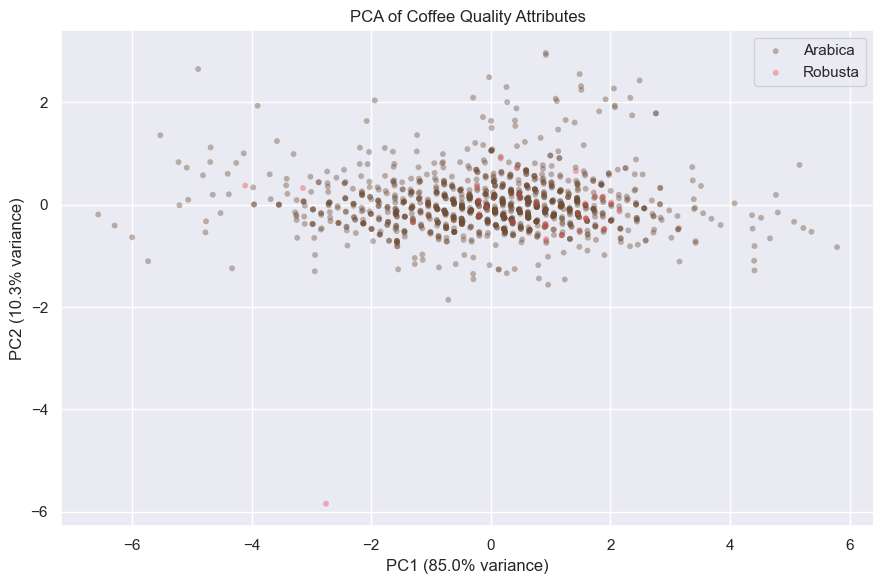

In [44]:
df_pca = df[radar_cols + ['Species','Total Cup Points','Country']].dropna()

scaler = StandardScaler()
X_sc   = scaler.fit_transform(df_pca[radar_cols])
pca    = PCA(n_components=2)
coords = pca.fit_transform(X_sc)

df_pca2 = pd.DataFrame(coords, columns=['PC1','PC2'])
df_pca2['Species'] = df_pca['Species'].values
df_pca2['Score']   = df_pca['Total Cup Points'].values
df_pca2['Country'] = df_pca['Country'].values

fig, ax = plt.subplots(figsize=(9, 6))
for sp, color in [('Arabica', C_BROWN), ('Robusta', C_RED)]:
    mask = df_pca2['Species']==sp
    ax.scatter(df_pca2.loc[mask,'PC1'], df_pca2.loc[mask,'PC2'],
               c=color, label=sp, alpha=0.4, s=18, edgecolors='none')
ax.set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)',
       ylabel=f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)',
       title='PCA of Coffee Quality Attributes')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PROC,'chem_05_pca.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5 · ML Model — Total Cup Points Predictor

In [45]:
df_ml = df.copy()
le_sp = LabelEncoder()
le_co = LabelEncoder()
df_ml['Species_enc'] = le_sp.fit_transform(df_ml['Species'])
df_ml['Country_enc'] = le_co.fit_transform(df_ml['Country'].astype(str))

feat_cols = radar_cols + ['Species_enc','Country_enc']
if 'altitude_mean_meters' in df_ml.columns:
    feat_cols.append('altitude_mean_meters')

df_model = df_ml[feat_cols + ['Total Cup Points']].dropna()
X = df_model[feat_cols]
y = df_model['Total Cup Points']

print(f'Features: {feat_cols}')
print(f'X shape: {X.shape}  |  Score range: {y.min():.1f} – {y.max():.1f}')

Features: ['Flavor', 'Aftertaste', 'Balance', 'Species_enc', 'Country_enc', 'altitude_mean_meters']
X shape: (1103, 6)  |  Score range: 63.1 – 90.6


In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(
    n_estimators=300, max_depth=10,
    min_samples_leaf=2, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

rmse_q = np.sqrt(mean_squared_error(y_test, y_pred))
r2_q   = r2_score(y_test, y_pred)
cv_q   = cross_val_score(rf, X, y, cv=5, scoring='r2')

print(f'RMSE : {rmse_q:.3f}')
print(f'R²   : {r2_q:.4f}')
print(f'CV R²: {cv_q.round(3)}  →  mean = {cv_q.mean():.3f}')

RMSE : 0.992
R²   : 0.8459
CV R²: [-2.496 -7.768 -7.087 -6.106 -0.84 ]  →  mean = -4.859


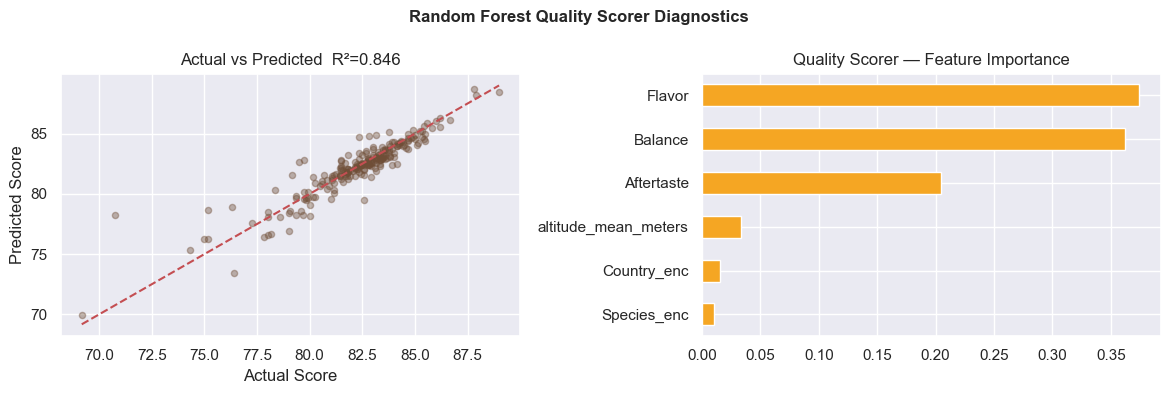

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, y_pred, alpha=0.4, color=C_BROWN, s=20)
mn, mx = float(y_test.min()), float(y_test.max())
axes[0].plot([mn,mx],[mn,mx],'r--',lw=1.5)
axes[0].set(title=f'Actual vs Predicted  R²={r2_q:.3f}',
            xlabel='Actual Score', ylabel='Predicted Score')

fi = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=True)
fi.plot(kind='barh', color=C_GOLD, ax=axes[1])
axes[1].set(title='Quality Scorer — Feature Importance')

plt.suptitle('Random Forest Quality Scorer Diagnostics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROC,'chem_06_model_diagnostics.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6 · Save All Artifacts

In [49]:
print(df.columns.tolist())

['Unnamed: 0', 'Species', 'Owner', 'Country', 'Farm.Name', 'Lot.Number', 'Mill', 'ICO.Number', 'Company', 'Altitude', 'Region', 'Producer', 'Number.of.Bags', 'Bag.Weight', 'In.Country.Partner', 'Year', 'Grading.Date', 'Owner.1', 'Variety', 'Processing.Method', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean.Cup', 'Sweetness', 'Cupper.Points', 'Total Cup Points', 'Moisture', 'Category.One.Defects', 'Quakers', 'Color', 'Category.Two.Defects', 'Expiration', 'Certification.Body', 'Certification.Address', 'Certification.Contact', 'unit_of_measurement', 'altitude_low_meters', 'altitude_high_meters', 'altitude_mean_meters', 'Fragrance...Aroma', 'Salt...Acid', 'Bitter...Sweet', 'Mouthfeel', 'Uniform.Cup']


In [50]:
# Save processed dataframe
df[['Country','Species','Year','altitude_mean_meters','Total Cup Points'] + QUALITY_COLS] \
    .dropna(subset=['Total Cup Points']) \
    .to_csv(os.path.join(PROC,'chem_processed.csv'), index=False)

# Save models
joblib.dump(rf,       os.path.join(MDL,'quality_scorer.pkl'))
joblib.dump(le_sp,    os.path.join(MDL,'quality_species_encoder.pkl'))
joblib.dump(le_co,    os.path.join(MDL,'quality_country_encoder.pkl'))
joblib.dump(feat_cols,os.path.join(MDL,'quality_features.pkl'))
joblib.dump(scaler,   os.path.join(MDL,'quality_pca_scaler.pkl'))
joblib.dump(pca,      os.path.join(MDL,'quality_pca.pkl'))
joblib.dump(radar_cols,os.path.join(MDL,'radar_cols.pkl'))

print('✅  Notebook 2 complete!')
print(f'    Quality Scorer R² = {r2_q:.3f}  |  RMSE = {rmse_q:.3f}')
print(f'    radar_cols: {radar_cols}')

✅  Notebook 2 complete!
    Quality Scorer R² = 0.846  |  RMSE = 0.992
    radar_cols: ['Flavor', 'Aftertaste', 'Balance']
